# Programação de Caminho Crítico do Lançamento de um Produto de Seguro Automóvel

## Resumo executivo

O lançamento de um produto de seguro automóvel pessoal é um programa multifuncional: os atuários precificam o risco, a área de compliance protocola as tarifas junto ao estado e aguarda aprovação, a TI configura o sistema de administração de apólices e a distribuição treina os corretores. Essas tarefas têm relações de precedência rígidas, portanto a data de lançamento é definida pela cadeia dependente mais longa do plano -- o **caminho crítico**.

Este notebook constrói uma rede de projeto Atividade-no-Nó (Activity-on-Node) de onze tarefas de lançamento e calcula uma programação completa pelo **Método do Caminho Crítico (CPM)** com **PROC OPTMODEL**. As passagens direta e reversa do CPM são programas lineares sobre o grafo de precedência: a passagem direta (caminho mais longo a partir do início) fornece o início e o término mais cedo de cada tarefa, e uma passagem reversa de caminho mais longo fornece o início e o término mais tarde e a **folga total** (schedule slack). Os resultados abaixo são produzidos inteiramente pelo código deste notebook -- cada número da narrativa é lido de volta a partir da saída executada.

**O que a programação mostra.** Em um calendário de trabalho de cinco dias ancorado em 01JUN2026, o programa se estende por **97 dias úteis** e termina em **13OCT2026**. Nove das onze tarefas estão no caminho crítico (Kickoff -> Market research -> Loss-data assembly -> Pricing -> System design -> System build -> UAT -> Agent training -> Launch) e carregam folga zero. Apenas o ramo regulatório -- **rate filing** e **approval** -- tem folga: cada um pode atrasar até **30 dias úteis** sem mover o lançamento, porque o ramo paralelo de construção do sistema é o mais longo dos dois caminhos convergentes.

## Como isto é construído

O CPM é classicamente um procedimento SAS/OR, mas seu cálculo central é um par de problemas de caminho mais longo no grafo de precedência, que o PROC OPTMODEL expressa diretamente como pequenos programas lineares:

- **Passagem direta (tempos mais cedo).** Minimizar as variáveis de início-mais-cedo sujeitas a `ES[successor] >= ES[predecessor] + duration + lag` para cada arco de precedência. No ótimo, cada `ES` é igual ao caminho mais longo a partir do início do projeto, isto é, o mais cedo que a tarefa pode começar.
- **Passagem reversa (tempos mais tarde / folga).** Calcular, para cada tarefa, o caminho remanescente mais longo até o fim do projeto (`TAIL`). O início mais tarde é então `makespan - TAIL`, e a **folga total** é `late start - early start`. Tarefas com folga zero são críticas.

A rede, as durações, os lags de precedência e as demandas de recursos por tarefa são todos gerados inline; não há entradas externas. As datas de calendário em dias úteis são derivadas com `INTNX('weekday', ...)` de modo que os fins de semana sejam ignorados.

## Dados

| Conjunto de dados | Linhas | Variáveis-chave | Descrição |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Cadastro de atividades: cada tarefa de lançamento, sua duração em dias úteis, e o número diário de atuários / desenvolvedores de que necessita |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Arcos de precedência da rede Atividade-no-Nó; `lag` é um atraso término-para-início em dias úteis (o período regulatório de espera após a aprovação) |

IDs numéricos de atividade indexam a rede para que o grafo de precedência seja lido de forma limpa no conjunto de tuplas do OPTMODEL; os nomes legíveis em `activity` são reunidos de volta à programação posteriormente.

In [1]:
DADOS acts;
   COMPRIMENTO activity $16;
   ENTRADA id activity $ dur actuary developer;
   DATALINES;
1 Kickoff       3 1 0
2 MarketRsch    8 2 0
3 LossData     10 3 0
4 Pricing       9 3 1
5 RateFiling    4 1 0
6 Approval      6 1 0
7 SystemDesign 12 1 2
8 SystemBuild  18 0 3
9 UAT          15 0 2
10 AgentTrain  20 1 1
11 Launch       2 1 1
;
EXECUTAR;

DADOS arcs;
   ENTRADA pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
EXECUTAR;

/* numeric-only view of durations for OPTMODEL */
DADOS acts_n; DEFINIR acts; MANTER id dur; EXECUTAR;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Passagem direta -- início e término mais cedo

A passagem direta é um PL de caminho mais longo. A restrição `ES[j] >= ES[i] + dur[i] + lag[i,j]` para cada arco força cada tarefa a começar não antes de todos os seus predecessores terminarem (mais qualquer lag regulatório); minimizar as variáveis de início-mais-cedo leva cada uma ao seu caminho predecessor mais longo. Gravamos os valores `ES` resolvidos diretamente da variável do OPTMODEL em `fwd`.

In [2]:
PROCEDIMENTO optmodel;
   DEFINIR NODES; num dur{NODES};
   READ DADOS acts_n INTO NODES=[id] dur=dur;

   DEFINIR <num,num> ARCS; num lag{ARCS};
   READ DADOS arcs INTO ARCS=[pred succ] lag=lag;

   VARIÁVEL ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CRIAR DADOS fwd DE_TABELA [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Passagem reversa -- tempos mais tarde e folga total

`TAIL[a]` é o caminho mais longo da tarefa `a` até o fim do projeto, portanto deve cobrir a duração da própria tarefa e, para cada sucessor, o lag mais o tail desse sucessor: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimizar os tails gera os valores mais justos. O **makespan** do projeto é o maior término mais cedo; o **início mais tarde** de cada tarefa é `makespan - TAIL`, e a **folga total** é `late start - early start`. Folga zero marca o caminho crítico.

In [3]:
PROCEDIMENTO optmodel;
   DEFINIR NODES; num dur{NODES};
   READ DADOS acts_n INTO NODES=[id] dur=dur;

   DEFINIR <num,num> ARCS; num lag{ARCS};
   READ DADOS arcs INTO ARCS=[pred succ] lag=lag;

   VARIÁVEL TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CRIAR DADOS bwd DE_TABELA [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Montar a programação e o calendário

Reunimos os inícios mais cedo e os tails de volta ao cadastro de atividades, derivamos o início / término mais tarde e a folga total, e mapeamos os deslocamentos em dias úteis para datas de calendário com `INTNX('weekday', ...)` de modo que as datas caiam em dias úteis. Uma tarefa é sinalizada como **crítica** quando sua folga total é zero.

In [4]:
%LET anchor = '01jun2026'd;

DADOS sched0;
   MESCLAR acts fwd bwd; POR id;
   ef = es + dur;            /* early finish */
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=sched0 NOPRINT;
   SAÍDA out=mk(REMOVER=_type_ _freq_) MAX(ef)=makespan;
EXECUTAR;

DADOS sched;
   SE _n_=1 ENTÃO DEFINIR mk;
   DEFINIR sched0;
   RETER mspan;
   SE _n_=1 ENTÃO mspan = makespan;
   ls = mspan - tail;        /* late start  */
   lf = ls + dur;            /* late finish */
   tfloat = ls - es;         /* total float */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   COMPRIMENTO cclass $10;
   SE critical ENTÃO cclass='Critical';
   SENÃO cclass='Float';
   FORMATO e_start e_finish l_start l_finish date9.;
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=sched out=sched_es; POR es id; EXECUTAR;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## A programação CPM

Início e término mais cedo/mais tarde estão em dias úteis a partir da âncora 01JUN2026 (dia 0). As tarefas na classe **Critical** têm folga total zero.

In [5]:
TÍTULO 'Programação CPM -- tempos em dias úteis e folga total';
PROCEDIMENTO IMPRIMIR DADOS=sched_es noobs RÓTULO;
   VARIÁVEL activity dur es ef ls lf tfloat cclass;
   RÓTULO activity='Atividade' dur='Dur(du)' es='IC' ef='TC'
         ls='IT' lf='TT' tfloat='Folga Total' cclass='Classe';
EXECUTAR;

                                 Programação CPM -- tempos em dias úteis e folga total                                  


   Atividade  Dur(du)  IC  TC  IT  TT  Folga Total    Classe
------------  -------  --  --  --  --  -----------  --------
Kickoff             3   0   3   0   3            0  Critical
MarketRsch          8   3  11   3  11            0  Critical
LossData           10  11  21  11  21            0  Critical
Pricing             9  21  30  21  30            0  Critical
RateFiling          4  30  34  60  64           30  Float
SystemDesign       12  30  42  30  42            0  Critical
Approval            6  34  40  64  70           30  Float
SystemBuild        18  42  60  42  60            0  Critical
UAT                15  60  75  60  75            0  Critical
AgentTrain         20  75  95  75  95            0  Critical
Launch              2  95  97  95  97            0  Critical




NOTE: Option TITLE changed to Programação CPM -- tempos em dias úteis e folga total.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


A coluna de início-mais-cedo traça a cadeia dependente: Kickoff começa no dia 0, e cada tarefa a jusante começa quando seus predecessores terminam. O projeto se conclui no maior término mais cedo.

## O caminho crítico

Listar apenas as tarefas de folga zero, com suas datas de calendário, fornece a cadeia que define a data de lançamento. Qualquer atraso nessas tarefas desloca o lançamento dia a dia.

In [6]:
TÍTULO 'Caminho crítico (Folga Total = 0) com datas de calendário';
PROCEDIMENTO IMPRIMIR DADOS=sched_es noobs RÓTULO;
   ONDE critical=1;
   VARIÁVEL activity dur e_start e_finish;
   RÓTULO activity='Atividade' dur='Dur(du)'
         e_start='Início Cedo' e_finish='Término Cedo';
EXECUTAR;

DADOS mkrep;
   DEFINIR mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   FORMATO anchor FINISH date9.;
EXECUTAR;
TÍTULO 'Duração do projeto';
PROCEDIMENTO IMPRIMIR DADOS=mkrep noobs RÓTULO;
   VARIÁVEL anchor makespan FINISH;
   RÓTULO anchor='Âncora (Dia 0)'
         makespan='Duração Total (dias úteis)'
         FINISH='Término Projetado';
EXECUTAR;

                               Caminho crítico (Folga Total = 0) com datas de calendário                                


   Atividade  Dur(du)   Início Cedo   Término Cedo
------------  -------  ------------  -------------
Kickoff             3     01JUN2026      03JUN2026
MarketRsch          8     04JUN2026      15JUN2026
LossData           10     16JUN2026      29JUN2026
Pricing             9     30JUN2026      10JUL2026
SystemDesign       12     13JUL2026      28JUL2026
SystemBuild        18     29JUL2026      21AUG2026
UAT                15     24AUG2026      11SEP2026
AgentTrain         20     14SEP2026      09OCT2026
Launch              2     12OCT2026      13OCT2026

                                                   Duração do projeto                                                   


 Âncora (Dia 0)     Duração Total (dias úteis)   Término Projetado
---------------  -----------------------------  ------------------
      01JUN2026                             97           1


NOTE: Option TITLE changed to Caminho crítico (Folga Total = 0) com datas de calendário.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Duração do projeto.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Onde está a folga

As tarefas não críticas são o ramo regulatório. Seu início / término mais tarde mostram quão longe cada uma pode se mover antes de começar a empurrar o lançamento. A folga livre aqui é igual à folga total porque nenhuma outra tarefa depende delas até que se reintegrem no agent training.

In [7]:
TÍTULO 'Atividades não críticas e sua folga de programação';
PROCEDIMENTO IMPRIMIR DADOS=sched_es noobs RÓTULO;
   ONDE critical=0;
   VARIÁVEL activity dur e_start e_finish l_start l_finish tfloat;
   RÓTULO activity='Atividade' dur='Dur(du)'
         e_start='Início Cedo' e_finish='Término Cedo'
         l_start='Início Tarde' l_finish='Término Tarde'
         tfloat='Folga Total';
EXECUTAR;

                                   Atividades não críticas e sua folga de programação                                   


 Atividade  Dur(du)   Início Cedo   Término Cedo   Início Tarde   Término Tarde  Folga Total
----------  -------  ------------  -------------  -------------  --------------  -----------
RateFiling        4     13JUL2026      16JUL2026      24AUG2026       27AUG2026           30
Approval          6     17JUL2026      24JUL2026      28AUG2026       04SEP2026           30




NOTE: Option TITLE changed to Atividades não críticas e sua folga de programação.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Cascata da programação

Uma barra alta-baixa por tarefa, desenhada do seu início mais cedo ao seu término mais cedo na ordem do projeto, fornece uma cascata estilo Gantt do plano. A altura de cada barra é a duração da tarefa, e a escada sobe até o makespan de 97 dias úteis. As tarefas que ficam *abaixo* da diagonal ascendente -- onde o topo de uma barra é mais baixo que a base da barra seguinte -- são as que têm folga.

                          Lançamento do produto automóvel -- cascata da programação mais cedo                           




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Lançamento do produto automóvel -- cascata da programação mais cedo.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


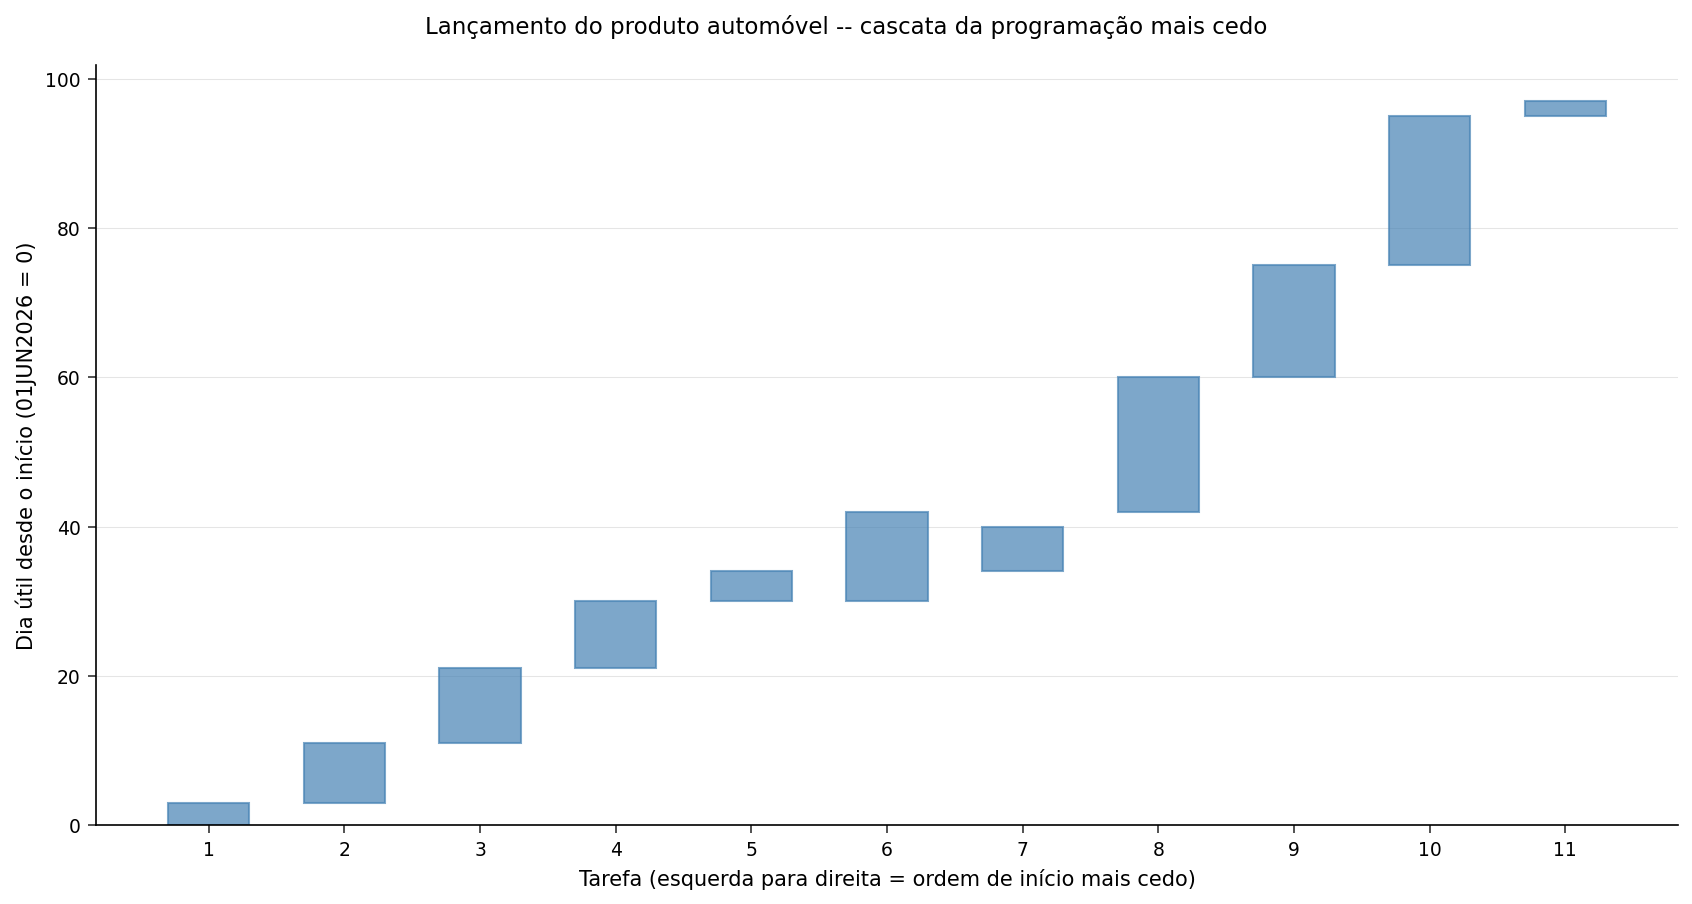

In [8]:
DADOS gantt; DEFINIR sched_es;
   ord = es;          /* numeric x = early-start order */
EXECUTAR;
PROCEDIMENTO ORDENAR DADOS=gantt; POR ord activity; EXECUTAR;
DADOS gantt; DEFINIR gantt; ax = _n_; EXECUTAR;   /* compact 1..11 x index */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TÍTULO 'Lançamento do produto automóvel -- cascata da programação mais cedo';
PROCEDIMENTO SGPLOT DADOS=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS RÓTULO='Tarefa (esquerda para direita = ordem de início mais cedo)'
         integer VALUES=(1 ATÉ 11 POR 1);
   YAXIS RÓTULO='Dia útil desde o início (01JUN2026 = 0)' grid;
EXECUTAR;
ODS GRAPHICS OFF;

Lendo da esquerda para a direita, as barras sobem continuamente pela cadeia crítica. As duas tarefas cujas barras quebram a escada -- começando mais abaixo que o topo da barra anterior -- são rate filing e approval, as atividades que carregam folga.

## Folga total por tarefa

Plotar a folga total de cada tarefa torna o caminho crítico inconfundível: cada tarefa crítica fica em zero, e apenas as duas tarefas regulatórias se elevam acima disso.

                                    Folga total por tarefa (0 = no caminho crítico)                                     




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Folga total por tarefa (0 = no caminho crítico).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


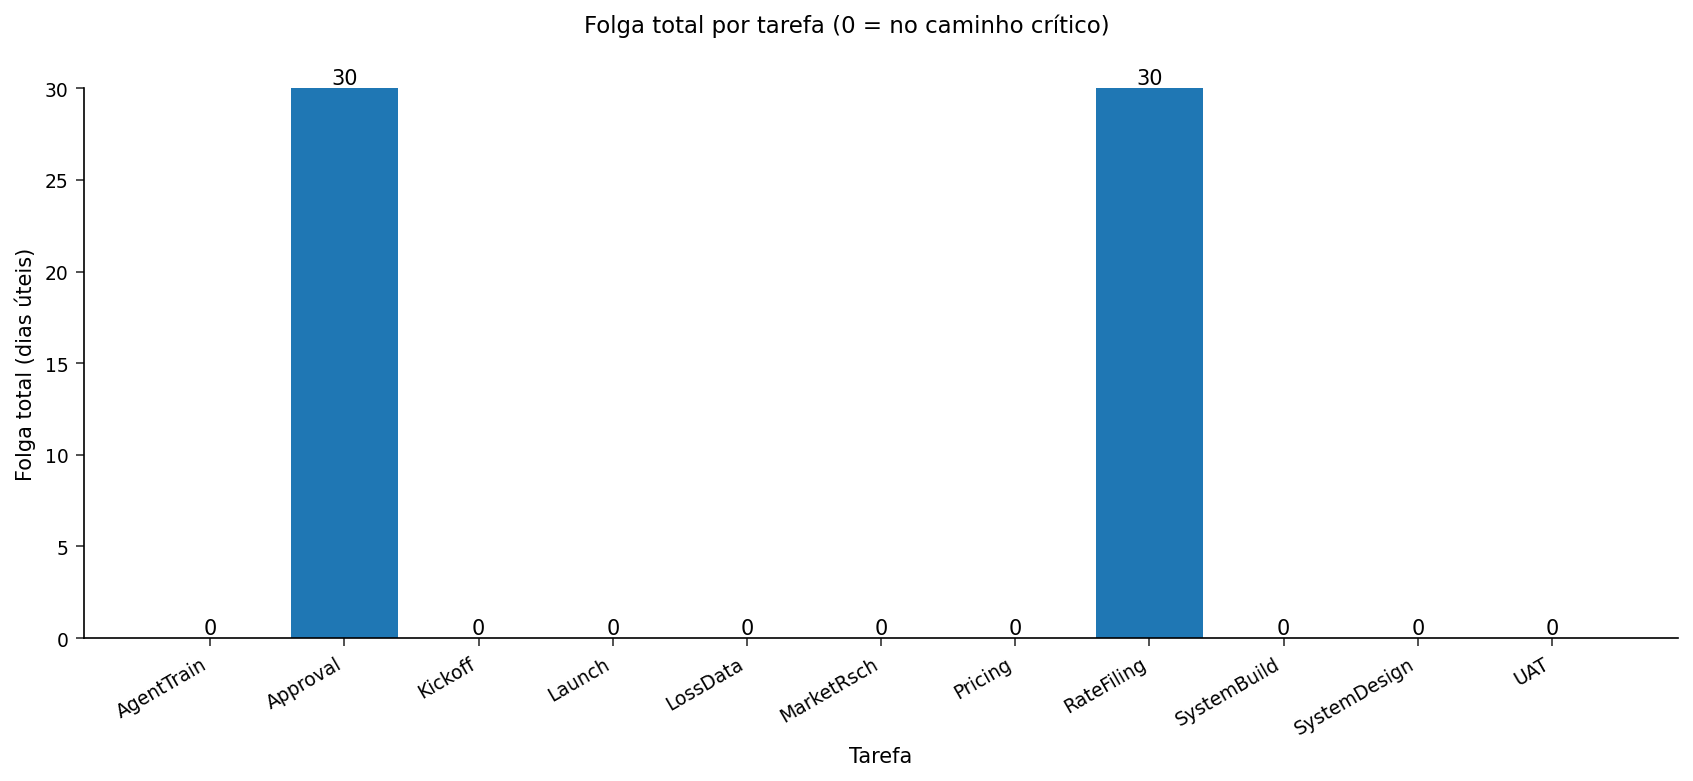

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TÍTULO 'Folga total por tarefa (0 = no caminho crítico)';
PROCEDIMENTO SGPLOT DADOS=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS RÓTULO='Tarefa' fitpolicy=rotatethin;
   YAXIS RÓTULO='Folga total (dias úteis)';
EXECUTAR;
ODS GRAPHICS OFF;

## Carga de recursos na programação mais cedo

Além do cronograma, o plano compete por dois grupos de especialistas. Expandir cada tarefa ao longo dos dias úteis que ocupa e somar a demanda diária fornece o perfil de carga de recursos -- quantos atuários e desenvolvedores o plano necessita a cada dia se toda tarefa começar o mais cedo possível. O pico é a maior capacidade que o programa exige de uma só vez.

                                Pico de carga diária de recursos (programação mais cedo)                                

                                                  The MEANS Procedure

 Variable    Label               Maximum
 ---------------------------------------
 ACTUARIES   Atuários                  3
 DEVELOPERS  Desenvolvedores           3
 ---------------------------------------

                          Carga diária de atuários e desenvolvedores na programação mais cedo                           




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Pico de carga diária de recursos (programação mais cedo).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Carga diária de atuários e desenvolvedores na programação mais cedo.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


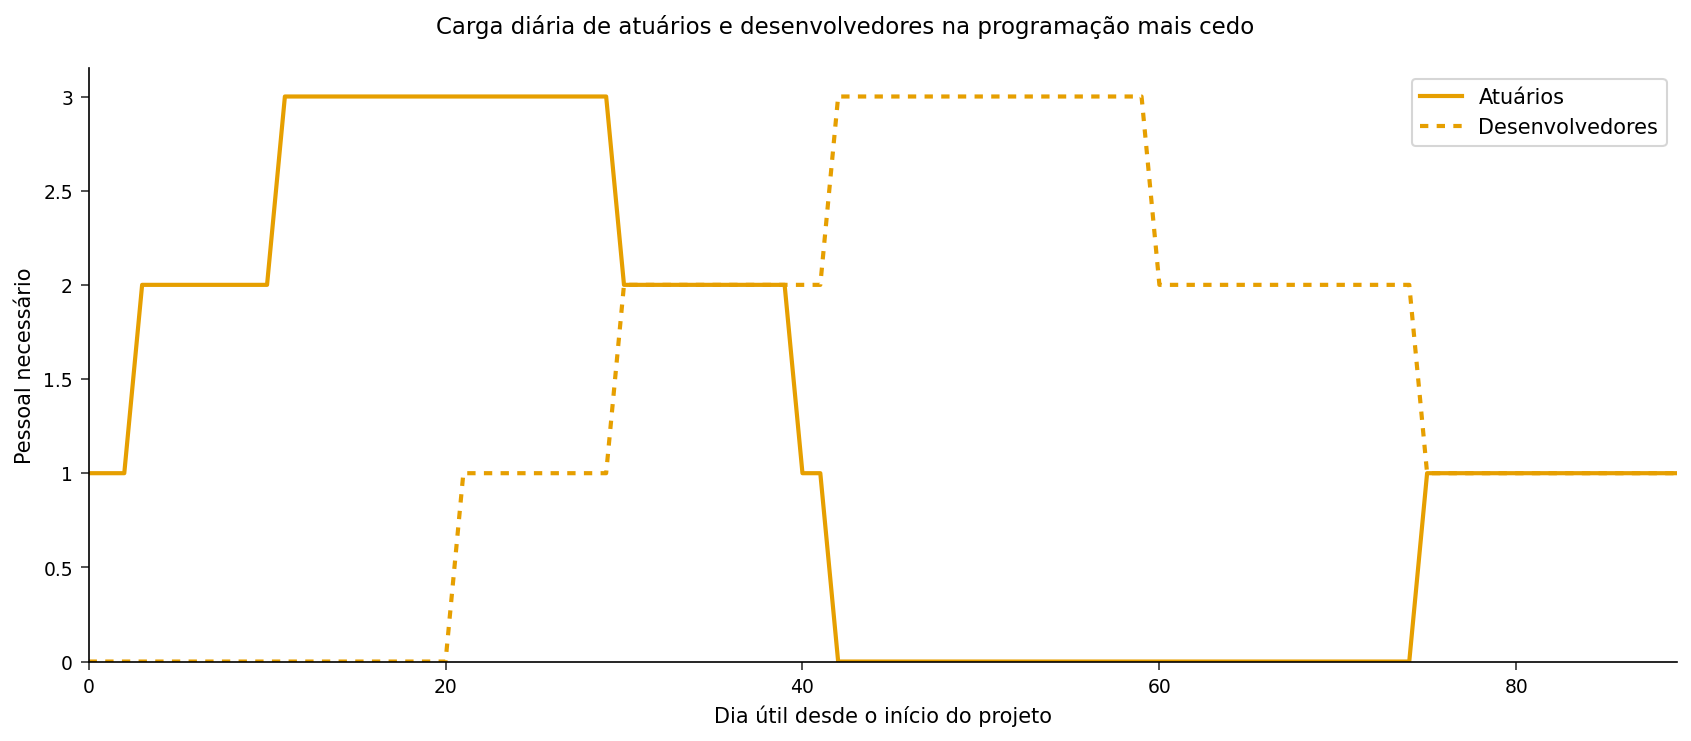

In [10]:
DADOS LOAD;
   DEFINIR sched;
   FAZER d = es ATÉ ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      SAÍDA;
   FIM;
   MANTER day a_use d_use;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=LOAD NOPRINT NWAY;
   CLASSE day;
   VARIÁVEL a_use d_use;
   SAÍDA out=rprofile(REMOVER=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
EXECUTAR;
PROCEDIMENTO ORDENAR DADOS=rprofile; POR day; EXECUTAR;

TÍTULO 'Pico de carga diária de recursos (programação mais cedo)';
PROCEDIMENTO MÉDIAS DADOS=rprofile MAX maxdec=0;
   VARIÁVEL actuaries developers;
   RÓTULO actuaries='Atuários' developers='Desenvolvedores';
EXECUTAR;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TÍTULO 'Carga diária de atuários e desenvolvedores na programação mais cedo';
PROCEDIMENTO SGPLOT DADOS=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Atuários';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Desenvolvedores';
   XAXIS RÓTULO='Dia útil desde o início do projeto';
   YAXIS RÓTULO='Pessoal necessário' MIN=0;
   keylegend / location=inside position=topright;
EXECUTAR;
ODS GRAPHICS OFF;

## Interpretando os resultados

- **A data de lançamento é definida pela trilha de construção, não pela trilha regulatória.** O caminho crítico percorre Kickoff -> Market research -> Loss-data assembly -> Pricing -> System design -> System build -> UAT -> Agent training -> Launch, para um makespan de 97 dias úteis (terminando em 13OCT2026). Cada uma dessas tarefas tem folga zero, portanto qualquer atraso nelas empurra o lançamento dia a dia.

- **O ramo regulatório tem um mês de folga.** Rate filing e approval carregam cada um 30 dias úteis de folga total. Depois que o pricing termina, eles podem começar tão tarde quanto suas datas de início mais tarde e ainda assim reintegrar-se ao agent training no prazo, porque o ramo paralelo de construção do sistema (system design -> system build -> UAT) é o mais longo dos dois caminhos que alimentam o lançamento. Em termos de planejamento, o protocolo regulatório *não* é a restrição vinculante aqui -- a construção do sistema de apólices é.

- **A demanda por especialistas atinge o pico em fases diferentes.** O perfil de carga mostra a demanda por atuários atingindo o pico cedo (até o pricing) e a demanda por desenvolvedores atingindo o pico mais tarde (até a construção do sistema), cada uma chegando ao máximo de três pessoas por dia. Como os dois picos ocorrem em fases diferentes, uma equipe de especialistas pequena e sequencial consegue dotar o plano -- o programa não precisa de seu número máximo de atuários e desenvolvedores simultaneamente.

**Conclusão de negócio.** O CPM transforma uma lista de tarefas de lançamento em uma programação acionável: identifica as atividades da trilha de construção que a seguradora deve proteger para atingir 13OCT2026, quantifica o mês de folga disponível no protocolo regulatório, e mostra que picos escalonados de atuários e desenvolvedores permitem que uma equipe enxuta de especialistas entregue o plano.

*Nota de implementação:* o SAS calcula isto com PROC CPM (SAS/OR). O Jenner alcança o mesmo resultado de caminho crítico direto/reverso com PROC OPTMODEL resolvendo os dois programas lineares de caminho mais longo que fundamentam o método.